# Contact Map Visualization (random-3-bins)

Visualize model-generated vs ground-truth contact maps for the random-3-bins
document format. Contacts include distance bins (< 4\u00c5, 4-12\u00c5, > 12\u00c5),
correction tokens, and a pLDDT bin token. Contacts are in random order.

In [1]:
# Config
CHECKPOINT_PATH = "../../outputs/exp5.ethereal-galaxy-3/checkpoint-125500"
PDB_ID = "1QYS"
CONTACT_DISTANCE_CUTOFF = 4.0  # bin_lt4 threshold
BIN_EDGES = [4.0, 12.0]  # must match training config
MAX_NEW_TOKENS = 3440
#PREFIX_SIZES = [0, 5, 10, 20]
PREFIX_SIZES = [0]
N_ROLLOUTS = 10
DEVICE = "cuda"

In [2]:
# Download & parse PDB structure
import tempfile
import numpy as np
from biotite.database import rcsb
from biotite.structure.io import pdbx
from biotite.structure import filter_amino_acids
from experiments.exp5_contact_prediction.src.data import AMINO_ACIDS, VALID_ATOMS

NONSTANDARD_AA_MAP = {
    "MSE": "MET", "CSE": "CYS", "SEC": "CYS", "HYP": "PRO",
    "TPO": "THR", "SEP": "SER", "PTR": "TYR",
}

path = rcsb.fetch(PDB_ID, "cif", tempfile.gettempdir())
cif = pdbx.CIFFile.read(path)
atoms = pdbx.get_structure(cif.block, model=1)

first_chain = atoms.chain_id[0]
chain_atoms = atoms[(atoms.chain_id == first_chain) & filter_amino_acids(atoms) & (atoms.element != "H")]

res_ids = chain_atoms.res_id
unique_res = sorted(set(res_ids))
res_id_to_pos = {rid: i + 1 for i, rid in enumerate(unique_res)}
sequence_raw = [chain_atoms[chain_atoms.res_id == rid].res_name[0] for rid in unique_res]

aa_set = set(AMINO_ACIDS)
sequence = []
for aa in sequence_raw:
    if aa in aa_set:
        sequence.append(aa)
    elif aa in NONSTANDARD_AA_MAP:
        print(f"  Mapping: {aa} -> {NONSTANDARD_AA_MAP[aa]}")
        sequence.append(NONSTANDARD_AA_MAP[aa])
    else:
        raise ValueError(f"Unknown amino acid: {aa}")

seq_len = len(sequence)
print(f"Protein {PDB_ID}: {seq_len} residues, chain {first_chain}")

  Mapping: MSE -> MET
Protein 1QYS: 92 residues, chain A


In [3]:
# Compute ground-truth contacts with distance bins
from scipy.spatial import KDTree

coords = chain_atoms.coord
atom_names = chain_atoms.atom_name
atom_res_ids = chain_atoms.res_id

all_known_atoms = set()
for aa in VALID_ATOMS:
    all_known_atoms.update(VALID_ATOMS[aa])

def assign_bin(dist):
    if dist < BIN_EDGES[0]:
        return "bin_lt4"
    elif dist < BIN_EDGES[1]:
        return "bin_4_12"
    else:
        return "bin_gt12"

# Collect ALL valid atom pairs with distances (no cutoff - we need all 3 bins)
# For bin_lt4: use KDTree with 4A cutoff
# For bin_4_12 and bin_gt12: sample from all residue pairs not in bin_lt4
# But for GT visualization we just need bin_lt4 contacts (the real contacts)
# since bin_4_12 and bin_gt12 are negatives/non-contacts
tree = KDTree(coords)
close_pairs = tree.query_pairs(r=CONTACT_DISTANCE_CUTOFF)

# Collect closest atom pair per residue pair within cutoff
all_atom_contacts = []
for i, j in close_pairs:
    ri, rj = atom_res_ids[i], atom_res_ids[j]
    pi, pj = res_id_to_pos.get(ri), res_id_to_pos.get(rj)
    if pi is None or pj is None:
        continue
    if abs(pi - pj) < 2:
        continue
    ai, aj = str(atom_names[i]), str(atom_names[j])
    if ai not in all_known_atoms or aj not in all_known_atoms:
        continue
    aa_i, aa_j = sequence[pi - 1], sequence[pj - 1]
    if aa_i not in VALID_ATOMS or ai not in VALID_ATOMS[aa_i]:
        continue
    if aa_j not in VALID_ATOMS or aj not in VALID_ATOMS[aa_j]:
        continue
    dist = float(np.linalg.norm(coords[i] - coords[j]))
    if pi > pj:
        all_atom_contacts.append((pj, pi, aj, ai, dist))
    else:
        all_atom_contacts.append((pi, pj, ai, aj, dist))

# Keep only the closest atom pair per residue pair
best_per_pair = {}
for contact in all_atom_contacts:
    pair_key = (contact[0], contact[1])
    if pair_key not in best_per_pair or contact[4] < best_per_pair[pair_key][4]:
        best_per_pair[pair_key] = contact

# Build GT contacts in exp5 format: (is_correction, pos1, pos2, atom1, atom2, bin)
# All GT contacts are non-correction, bin_lt4 (since they're within 4A)
# Randomize order (matching training data)
rng = np.random.RandomState(42)
gt_items = list(best_per_pair.values())
rng.shuffle(gt_items)
gt_contacts = [(False, p1, p2, a1, a2, assign_bin(d)) for p1, p2, a1, a2, d in gt_items]

gt_pair_set = {(c[1], c[2]) for c in gt_contacts}
print(f"Ground-truth contacts: {len(gt_contacts)} (one per residue pair, all bin_lt4)")

# Build the document prompt
seq_tokens = " ".join(f"<{aa}>" for aa in sequence)
base_prompt = f"<random-3-bins> <begin_sequence> {seq_tokens} <begin_contacts>"
print(f"Prompt length: {len(base_prompt.split())} tokens")

Ground-truth contacts: 257 (one per residue pair, all bin_lt4)
Prompt length: 95 tokens


In [4]:
# Load model & tokenizer
import torch
from pathlib import Path
from transformers import LlamaForCausalLM
from experiments.exp5_contact_prediction.src.train import create_tokenizer, parse_generated_contacts

ckpt_path = Path(CHECKPOINT_PATH)
print(f"Loading checkpoint: {ckpt_path}")

tokenizer = create_tokenizer()
model = LlamaForCausalLM.from_pretrained(str(ckpt_path), torch_dtype=torch.bfloat16)
model = model.to(DEVICE).eval()
end_token_id = tokenizer.convert_tokens_to_ids("<end>")
print(f"Model loaded: {sum(p.numel() for p in model.parameters()):,} parameters")

/home/ubuntu/llm-protein-experiments/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading checkpoint: ../../outputs/exp5.ethereal-galaxy-3/checkpoint-125500


Loading weights: 100%|██████████| 147/147 [00:00<00:00, 383.16it/s, Materializing param=model.norm.weight]                              


Model loaded: 984,528,896 parameters


In [5]:
# Generate contacts: greedy + sampled rollouts for each prefix size
import time
from collections import Counter

generated_contacts = {}  # prefix_size -> greedy contacts
rollout_contacts = {}    # prefix_size -> list of N_ROLLOUTS contact lists
rollout_plddts = {}      # prefix_size -> list of N_ROLLOUTS plddt tokens (or None)
timings = {}             # prefix_size -> {"greedy": seconds, "rollouts": [seconds, ...]}

def build_prompt(n_prefix):
    if n_prefix > 0 and gt_contacts:
        prefix_toks = []
        for is_corr, p1, p2, a1, a2, bin_tok in gt_contacts[:n_prefix]:
            corr_tok = "<correction>" if is_corr else "<non-correction>"
            prefix_toks.extend([corr_tok, f"<p{p1}>", f"<p{p2}>", f"<{a1}>", f"<{a2}>", f"<{bin_tok}>"])
        return base_prompt + " " + " ".join(prefix_toks)
    return base_prompt

def run_generation(prompt, do_sample=False):
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=8192)
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
    gen_kwargs = dict(
        max_new_tokens=MAX_NEW_TOKENS,
        pad_token_id=tokenizer.pad_token_id,
        eos_token_id=end_token_id,
    )
    if do_sample:
        gen_kwargs.update(do_sample=True, temperature=1.0, top_k=0)
    else:
        gen_kwargs.update(do_sample=False)

    t0 = time.time()
    with torch.no_grad():
        outputs = model.generate(**inputs, **gen_kwargs)
    elapsed = time.time() - t0

    gen_ids = outputs[0][inputs["input_ids"].shape[1]:]
    gen_text = tokenizer.decode(gen_ids, skip_special_tokens=False)
    contacts, valid_grammar, plddt = parse_generated_contacts(gen_text.split())
    return contacts, valid_grammar, plddt, elapsed

for n_prefix in PREFIX_SIZES:
    prompt = build_prompt(n_prefix)
    timing_info = {}

    # Greedy
    contacts, valid, plddt, elapsed = run_generation(prompt, do_sample=False)
    if n_prefix > 0:
        contacts = list(gt_contacts[:n_prefix]) + list(contacts)
    generated_contacts[n_prefix] = contacts
    timing_info["greedy"] = elapsed
    bins = Counter(c[5] for c in contacts)
    print(f"Prefix {n_prefix:2d} greedy: {len(contacts):4d} contacts, valid={valid}, "
          f"plddt={plddt}, bins={dict(bins)}, {elapsed:.1f}s")

    # Sampled rollouts
    rollouts = []
    rollout_times = []
    plddts = []
    for r in range(N_ROLLOUTS):
        contacts_r, valid_r, plddt_r, elapsed_r = run_generation(prompt, do_sample=True)
        if n_prefix > 0:
            contacts_r = list(gt_contacts[:n_prefix]) + list(contacts_r)
        rollouts.append(contacts_r)
        rollout_times.append(elapsed_r)
        plddts.append(plddt_r)
    rollout_contacts[n_prefix] = rollouts
    rollout_plddts[n_prefix] = plddts
    timing_info["rollouts"] = rollout_times
    timings[n_prefix] = timing_info
    print(f"  rollouts: {N_ROLLOUTS}x, avg {np.mean(rollout_times):.1f}s each")

Prefix  0 greedy:   53 contacts, valid=True, plddt=None, bins={'bin_lt4': 39, 'bin_4_12': 10, 'bin_gt12': 4}, 5.2s
  rollouts: 10x, avg 27.5s each


In [6]:
# Show a full example rollout (first sampled rollout at prefix=0)
example_rollout = rollout_contacts[0][0]  # prefix=0, rollout index 0
print(f"Example rollout (prefix=0, rollout #0): {len(example_rollout)} contacts\n")

bins = Counter(c[5] for c in example_rollout)
corrections = sum(1 for c in example_rollout if c[0])
print(f"Distance bins: {dict(bins)}")
print(f"Corrections: {corrections} / {len(example_rollout)}")
print()

# Reconstruct the document text
doc_tokens = [base_prompt]
for is_corr, p1, p2, a1, a2, bin_tok in example_rollout:
    corr_tok = "<correction>" if is_corr else "<non-correction>"
    doc_tokens.append(f"{corr_tok} <p{p1}> <p{p2}> <{a1}> <{a2}> <{bin_tok}>")

print("Generated document:")
print(base_prompt)
for i, (is_corr, p1, p2, a1, a2, bin_tok) in enumerate(example_rollout):
    corr = "correction" if is_corr else "non-corr   "
    print(f"  [{i:3d}] {corr}  p{p1:>3d} p{p2:>3d}  {a1:>4s} {a2:>4s}  {bin_tok}")
    if i >= 40:
        print(f"  ... ({len(example_rollout) - 41} more contacts)")
        break

Example rollout (prefix=0, rollout #0): 331 contacts

Distance bins: {'bin_4_12': 57, 'bin_gt12': 27, 'bin_lt4': 247}
Corrections: 1 / 331

Generated document:
<random-3-bins> <begin_sequence> <ASP> <ILE> <GLN> <VAL> <GLN> <VAL> <ASN> <ILE> <ASP> <ASP> <ASN> <GLY> <LYS> <ASN> <PHE> <ASP> <TYR> <THR> <TYR> <THR> <VAL> <THR> <THR> <GLU> <SER> <GLU> <LEU> <GLN> <LYS> <VAL> <LEU> <ASN> <GLU> <LEU> <MET> <ASP> <TYR> <ILE> <LYS> <LYS> <GLN> <GLY> <ALA> <LYS> <ARG> <VAL> <ARG> <ILE> <SER> <ILE> <THR> <ALA> <ARG> <THR> <LYS> <LYS> <GLU> <ALA> <GLU> <LYS> <PHE> <ALA> <ALA> <ILE> <LEU> <ILE> <LYS> <VAL> <PHE> <ALA> <GLU> <LEU> <GLY> <TYR> <ASN> <ASP> <ILE> <ASN> <VAL> <THR> <PHE> <ASP> <GLY> <ASP> <THR> <VAL> <THR> <VAL> <GLU> <GLY> <GLN> <LEU> <begin_contacts>
  [  0] non-corr     p  7 p 44     O    C  bin_4_12
  [  1] non-corr     p 17 p 82     O    N  bin_gt12
  [  2] non-corr     p 19 p 30    CB  CG1  bin_lt4
  [  3] non-corr     p 81 p 83    CZ    O  bin_lt4
  [  4] non-corr     p 79 p 87  

In [7]:
2

2

In [8]:
# Build contact matrices
# For heatmaps: collapse to residue pairs (ignore atoms/bins/corrections)
def contacts_to_matrix(contacts, seq_len):
    matrix = np.zeros((seq_len, seq_len), dtype=np.float32)
    for c in contacts:
        p1, p2 = c[1], c[2]
        if 1 <= p1 <= seq_len and 1 <= p2 <= seq_len:
            matrix[p1 - 1, p2 - 1] = 1
            matrix[p2 - 1, p1 - 1] = 1
    return matrix

def contacts_to_pair_set(contacts):
    return {(min(c[1], c[2]), max(c[1], c[2])) for c in contacts}

# For bin-colored heatmaps: 1=bin_lt4, 2=bin_4_12, 3=bin_gt12
BIN_TO_VAL = {"bin_lt4": 1, "bin_4_12": 2, "bin_gt12": 3}
def contacts_to_bin_matrix(contacts, seq_len):
    """Build matrix where value indicates distance bin (last seen wins for corrections)."""
    matrix = np.zeros((seq_len, seq_len), dtype=np.float32)
    for c in contacts:
        p1, p2, bin_tok = c[1], c[2], c[5]
        if 1 <= p1 <= seq_len and 1 <= p2 <= seq_len:
            val = BIN_TO_VAL.get(bin_tok, 0)
            matrix[p1 - 1, p2 - 1] = val
            matrix[p2 - 1, p1 - 1] = val
    return matrix

gt_matrix = contacts_to_matrix(gt_contacts, seq_len)

# Greedy: separate prefix and generated-only
prefix_matrices = {}
gen_only_matrices = {}
gen_bin_matrices = {}
gen_accuracy = {}

for n_prefix, contacts in generated_contacts.items():
    prefix_contacts = contacts[:n_prefix] if n_prefix > 0 else []
    gen_only = contacts[n_prefix:] if n_prefix > 0 else contacts

    prefix_matrices[n_prefix] = contacts_to_matrix(prefix_contacts, seq_len)
    gen_only_matrices[n_prefix] = contacts_to_matrix(gen_only, seq_len)
    gen_bin_matrices[n_prefix] = contacts_to_bin_matrix(contacts, seq_len)

    # Accuracy: match on residue pair only (bin_lt4 contacts = true positives)
    gen_pairs = contacts_to_pair_set(gen_only)
    # Only count bin_lt4 generated contacts as "predicted positives"
    gen_lt4_pairs = {(min(c[1], c[2]), max(c[1], c[2])) for c in gen_only if c[5] == "bin_lt4"}
    n_gen = len(gen_lt4_pairs)
    n_correct = len(gen_lt4_pairs & gt_pair_set)
    precision = n_correct / n_gen if n_gen > 0 else 0.0
    recall = n_correct / len(gt_pair_set) if gt_pair_set else 0.0
    gen_accuracy[n_prefix] = {
        "n_gen_pairs": n_gen, "n_correct": n_correct,
        "precision": precision, "recall": recall,
        "n_total_contacts": len(gen_only),
    }

# Rollout frequency (bin_lt4 contacts only for the contact map)
rollout_freq_matrices = {}
rollout_accuracy = {}

for n_prefix, rollouts in rollout_contacts.items():
    freq = np.zeros((seq_len, seq_len), dtype=np.float32)
    for contacts in rollouts:
        gen_only = contacts[n_prefix:] if n_prefix > 0 else contacts
        # Only count bin_lt4 contacts
        lt4 = [c for c in gen_only if c[5] == "bin_lt4"]
        m = contacts_to_matrix(lt4, seq_len)
        freq += m
    freq /= len(rollouts)
    rollout_freq_matrices[n_prefix] = freq

    predicted_pairs = set()
    for i in range(seq_len):
        for j in range(i + 1, seq_len):
            if freq[i, j] > 0.5:
                predicted_pairs.add((i + 1, j + 1))
    n_pred = len(predicted_pairs)
    n_correct = len(predicted_pairs & gt_pair_set)
    precision = n_correct / n_pred if n_pred > 0 else 0.0
    recall = n_correct / len(gt_pair_set) if gt_pair_set else 0.0
    rollout_accuracy[n_prefix] = {
        "n_pred_pairs": n_pred, "n_correct": n_correct,
        "precision": precision, "recall": recall,
    }

print(f"Ground truth: {len(gt_pair_set)} unique residue pairs (bin_lt4)\n")
print("Greedy (bin_lt4 contacts as predictions):")
for k, acc in gen_accuracy.items():
    print(f"  Prefix {k:2d}: {acc['n_gen_pairs']} lt4 pairs, "
          f"{acc['n_correct']} correct, "
          f"prec={acc['precision']:.1%}, rec={acc['recall']:.1%}, "
          f"total_contacts={acc['n_total_contacts']}")
print(f"\nRollout consensus (>50% of {N_ROLLOUTS} rollouts, bin_lt4):")
for k, acc in rollout_accuracy.items():
    print(f"  Prefix {k:2d}: {acc['n_pred_pairs']} pred pairs, "
          f"{acc['n_correct']} correct, "
          f"prec={acc['precision']:.1%}, rec={acc['recall']:.1%}")

Ground truth: 257 unique residue pairs (bin_lt4)

Greedy (bin_lt4 contacts as predictions):
  Prefix  0: 39 lt4 pairs, 39 correct, prec=100.0%, rec=15.2%, total_contacts=53

Rollout consensus (>50% of 10 rollouts, bin_lt4):
  Prefix  0: 173 pred pairs, 154 correct, prec=89.0%, rec=59.9%


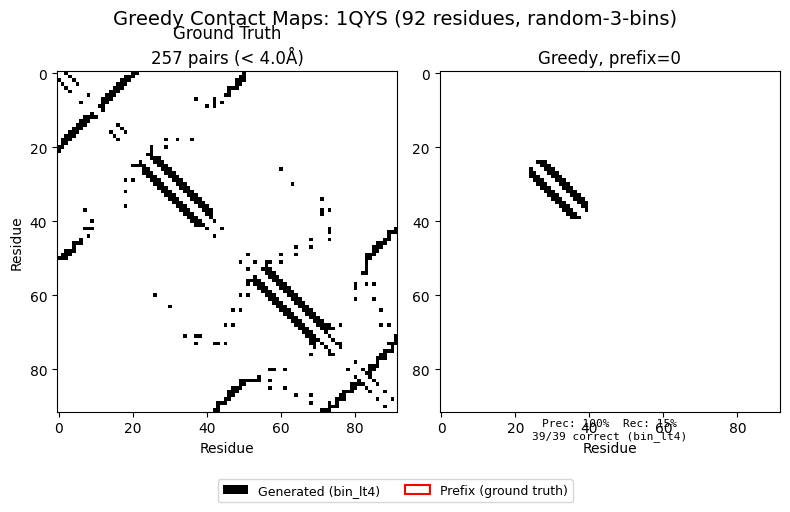

In [9]:
# Plot greedy heatmaps (bin_lt4 contacts only) with red circles on prefix
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch, Circle

n_cols = 1 + len(PREFIX_SIZES)
fig, axes = plt.subplots(1, n_cols, figsize=(4 * n_cols, 4.8), squeeze=False)
axes = axes[0]
cmap_bw = ListedColormap(["white", "black"])

# Ground truth
axes[0].imshow(gt_matrix, cmap=cmap_bw, vmin=0, vmax=1, origin="upper", aspect="equal")
axes[0].set_title(f"Ground Truth\n{len(gt_pair_set)} pairs (< {CONTACT_DISTANCE_CUTOFF}\u00c5)")
axes[0].set_xlabel("Residue")
axes[0].set_ylabel("Residue")

for i, n_prefix in enumerate(PREFIX_SIZES):
    ax = axes[i + 1]
    acc = gen_accuracy[n_prefix]

    # Show only bin_lt4 generated contacts
    gen_only = generated_contacts[n_prefix][n_prefix:] if n_prefix > 0 else generated_contacts[n_prefix]
    lt4_only = [c for c in gen_only if c[5] == "bin_lt4"]
    m = contacts_to_matrix(lt4_only, seq_len)
    ax.imshow(m, cmap=cmap_bw, vmin=0, vmax=1, origin="upper", aspect="equal")

    # Red circles for prefix
    if n_prefix > 0:
        prefix_pairs_plotted = set()
        for c in gt_contacts[:n_prefix]:
            pair = (min(c[1], c[2]) - 1, max(c[1], c[2]) - 1)
            if pair not in prefix_pairs_plotted:
                prefix_pairs_plotted.add(pair)
                for (r, col) in [(pair[0], pair[1]), (pair[1], pair[0])]:
                    ax.add_patch(Circle((col, r), radius=1.5, fill=False,
                                        edgecolor="red", linewidth=1.5))

    ax.set_title(f"Greedy, prefix={n_prefix}")
    ax.set_xlabel("Residue")
    ax.text(0.5, -0.02,
            f"Prec: {acc['precision']:.0%}  Rec: {acc['recall']:.0%}\n"
            f"{acc['n_correct']}/{acc['n_gen_pairs']} correct (bin_lt4)",
            transform=ax.transAxes, ha="center", va="top", fontsize=8, fontfamily="monospace")

fig.legend(handles=[
    Patch(facecolor="black", label="Generated (bin_lt4)"),
    Patch(facecolor="white", edgecolor="red", linewidth=1.5, label="Prefix (ground truth)"),
], loc="lower center", ncol=2, fontsize=9, bbox_to_anchor=(0.5, -0.02))
fig.suptitle(f"Greedy Contact Maps: {PDB_ID} ({seq_len} residues, random-3-bins)",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
plt.show()

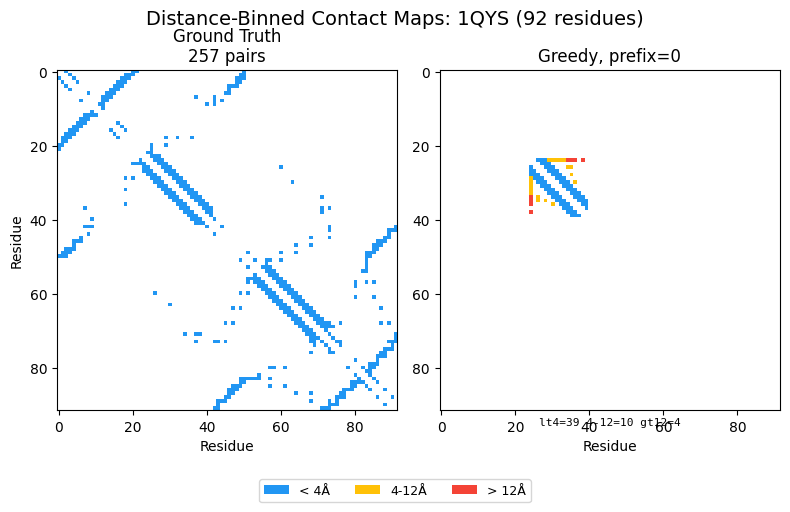

In [10]:
# Plot bin-colored heatmaps (greedy, all 3 distance bins)
from matplotlib.colors import ListedColormap

cmap_bins = ListedColormap(["white", "#2196F3", "#FFC107", "#F44336"])  # none, lt4, 4-12, gt12

n_cols = 1 + len(PREFIX_SIZES)
fig, axes = plt.subplots(1, n_cols, figsize=(4 * n_cols, 4.8), squeeze=False)
axes = axes[0]

# Ground truth (all bin_lt4)
gt_bin_matrix = contacts_to_bin_matrix(gt_contacts, seq_len)
axes[0].imshow(gt_bin_matrix, cmap=cmap_bins, vmin=0, vmax=3, origin="upper", aspect="equal")
axes[0].set_title(f"Ground Truth\n{len(gt_pair_set)} pairs")
axes[0].set_xlabel("Residue")
axes[0].set_ylabel("Residue")

for i, n_prefix in enumerate(PREFIX_SIZES):
    ax = axes[i + 1]
    m = gen_bin_matrices[n_prefix]
    ax.imshow(m, cmap=cmap_bins, vmin=0, vmax=3, origin="upper", aspect="equal")

    contacts = generated_contacts[n_prefix]
    bins = Counter(c[5] for c in contacts)
    ax.set_title(f"Greedy, prefix={n_prefix}")
    ax.set_xlabel("Residue")
    ax.text(0.5, -0.02,
            f"lt4={bins.get('bin_lt4',0)} 4-12={bins.get('bin_4_12',0)} gt12={bins.get('bin_gt12',0)}",
            transform=ax.transAxes, ha="center", va="top", fontsize=8, fontfamily="monospace")

fig.legend(handles=[
    Patch(facecolor="#2196F3", label="< 4\u00c5"),
    Patch(facecolor="#FFC107", label="4-12\u00c5"),
    Patch(facecolor="#F44336", label="> 12\u00c5"),
], loc="lower center", ncol=3, fontsize=9, bbox_to_anchor=(0.5, -0.02))
fig.suptitle(f"Distance-Binned Contact Maps: {PDB_ID} ({seq_len} residues)",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
plt.show()

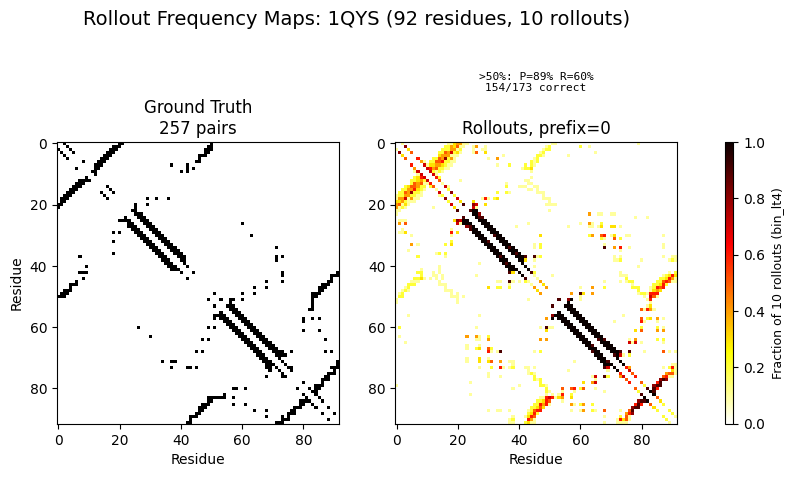

In [11]:
# Plot rollout frequency heatmaps (bin_lt4 contacts)
n_cols = 1 + len(PREFIX_SIZES)
fig, axes = plt.subplots(1, n_cols, figsize=(4 * n_cols, 5.2), squeeze=False)
axes = axes[0]

axes[0].imshow(gt_matrix, cmap="Greys", vmin=0, vmax=1, origin="upper", aspect="equal")
axes[0].set_title(f"Ground Truth\n{len(gt_pair_set)} pairs")
axes[0].set_xlabel("Residue")
axes[0].set_ylabel("Residue")

for i, n_prefix in enumerate(PREFIX_SIZES):
    ax = axes[i + 1]
    acc = rollout_accuracy[n_prefix]
    freq = rollout_freq_matrices[n_prefix]
    im = ax.imshow(freq, cmap="hot_r", vmin=0, vmax=1, origin="upper", aspect="equal")

    if n_prefix > 0:
        prefix_pairs_plotted = set()
        for c in gt_contacts[:n_prefix]:
            pair = (min(c[1], c[2]) - 1, max(c[1], c[2]) - 1)
            if pair not in prefix_pairs_plotted:
                prefix_pairs_plotted.add(pair)
                for (r, col) in [(pair[0], pair[1]), (pair[1], pair[0])]:
                    ax.add_patch(Circle((col, r), radius=1.5, fill=False,
                                        edgecolor="blue", linewidth=1.5))

    ax.set_title(f"Rollouts, prefix={n_prefix}")
    ax.set_xlabel("Residue")
    ax.text(0.5, 1.25,
            f">50%: P={acc['precision']:.0%} R={acc['recall']:.0%}\n"
            f"{acc['n_correct']}/{acc['n_pred_pairs']} correct",
            transform=ax.transAxes, ha="center", va="top", fontsize=8, fontfamily="monospace")

#cbar = fig.colorbar(im, ax=axes[-1], shrink=0.8, pad=0.02)
#cbar.set_label(f"Fraction of {N_ROLLOUTS} rollouts (bin_lt4)", fontsize=9)

from mpl_toolkits.axes_grid1.inset_locator import inset_axes

cax = inset_axes(
    axes[-1],
    width="3%",          # colorbar width
    height="100%",       # same height as the axes
    loc="lower right",
    bbox_to_anchor=(1.4, 0, 1, 1),
    bbox_transform=axes[0].transAxes,
    borderpad=0,
)

cbar = fig.colorbar(im, cax=cax)
cbar.set_label(f"Fraction of {N_ROLLOUTS} rollouts (bin_lt4)", fontsize=9)


fig.suptitle(f"Rollout Frequency Maps: {PDB_ID} ({seq_len} residues, {N_ROLLOUTS} rollouts)",
             fontsize=14, y=1.02)
#plt.tight_layout()
#plt.subplots_adjust(bottom=0.18)
plt.show()

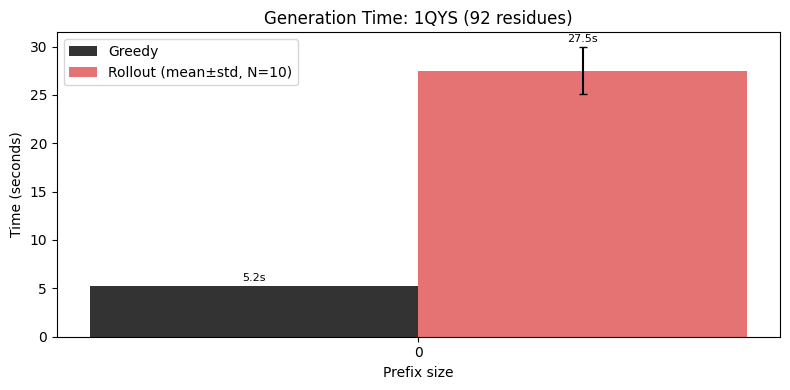

In [12]:
# Plot generation timings
fig, ax = plt.subplots(figsize=(8, 4))

x = np.arange(len(PREFIX_SIZES))
width = 0.25

greedy_times = [timings[p]["greedy"] for p in PREFIX_SIZES]
bars1 = ax.bar(x - width/2, greedy_times, width, label="Greedy", color="#333333")

rollout_means = [np.mean(timings[p]["rollouts"]) for p in PREFIX_SIZES]
rollout_stds = [np.std(timings[p]["rollouts"]) for p in PREFIX_SIZES]
bars2 = ax.bar(x + width/2, rollout_means, width, yerr=rollout_stds,
               label=f"Rollout (mean\u00b1std, N={N_ROLLOUTS})", color="#E57373", capsize=3)

ax.set_xlabel("Prefix size")
ax.set_ylabel("Time (seconds)")
ax.set_title(f"Generation Time: {PDB_ID} ({seq_len} residues)")
ax.set_xticks(x)
ax.set_xticklabels([str(p) for p in PREFIX_SIZES])
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{bar.get_height():.1f}s", ha="center", va="bottom", fontsize=8)
for bar, std in zip(bars2, rollout_stds):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.3,
            f"{bar.get_height():.1f}s", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
# Contact accuracy by sequence separation: short-range (< 6) vs long-range (>= 6)
SEP_THRESHOLD = 6

def compute_accuracy_by_range(contacts, gt_pair_set, threshold):
    """Split contacts into short/long range and compute accuracy for each."""
    lt4_contacts = [c for c in contacts if c[5] == "bin_lt4"]
    short_gen = {(min(c[1], c[2]), max(c[1], c[2])) for c in lt4_contacts if abs(c[1] - c[2]) < threshold}
    long_gen = {(min(c[1], c[2]), max(c[1], c[2])) for c in lt4_contacts if abs(c[1] - c[2]) >= threshold}
    short_gt = {p for p in gt_pair_set if abs(p[0] - p[1]) < threshold}
    long_gt = {p for p in gt_pair_set if abs(p[0] - p[1]) >= threshold}

    results = {}
    for label, gen_pairs, gt_pairs in [("short", short_gen, short_gt), ("long", long_gen, long_gt)]:
        n_gen = len(gen_pairs)
        n_correct = len(gen_pairs & gt_pairs)
        results[label] = {
            "n_gen": n_gen,
            "n_gt": len(gt_pairs),
            "n_correct": n_correct,
            "precision": n_correct / n_gen if n_gen > 0 else 0.0,
            "recall": n_correct / len(gt_pairs) if gt_pairs else 0.0,
        }
    return results

# Compute for greedy and rollout consensus at prefix=0
greedy_range = compute_accuracy_by_range(generated_contacts[0], gt_pair_set, SEP_THRESHOLD)

# Rollout consensus
freq = rollout_freq_matrices[0]
consensus_contacts = []
for i in range(seq_len):
    for j in range(i + 1, seq_len):
        if freq[i, j] > 0.1:
            consensus_contacts.append((False, i + 1, j + 1, "", "", "bin_lt4"))
consensus_range = compute_accuracy_by_range(consensus_contacts, gt_pair_set, SEP_THRESHOLD)

short_gt = greedy_range['short']['n_gt']
long_gt = greedy_range['long']['n_gt']
print(f"Sequence separation threshold: {SEP_THRESHOLD}")
print(f"GT: {short_gt} short-range, {long_gt} long-range")
print()
print("Greedy (prefix=0):")
for label in ["short", "long"]:
    r = greedy_range[label]
    cmp = '<' if label == 'short' else '>='
    print(f"  {label:>5s} (|i-j| {cmp} {SEP_THRESHOLD}): "
          f"prec={r['precision']:.1%} rec={r['recall']:.1%} "
          f"({r['n_correct']}/{r['n_gen']} correct, {r['n_gt']} GT)")
print()
print(f"Rollout consensus (prefix=0, >50% of {N_ROLLOUTS}):")
for label in ["short", "long"]:
    r = consensus_range[label]
    cmp = '<' if label == 'short' else '>='
    print(f"  {label:>5s} (|i-j| {cmp} {SEP_THRESHOLD}): "
          f"prec={r['precision']:.1%} rec={r['recall']:.1%} "
          f"({r['n_correct']}/{r['n_gen']} correct, {r['n_gt']} GT)")

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, metric, metric_label in zip(axes, ["precision", "recall"], ["Precision", "Recall"]):
    x = np.arange(2)
    width = 0.3
    greedy_vals = [greedy_range["short"][metric], greedy_range["long"][metric]]
    cons_vals = [consensus_range["short"][metric], consensus_range["long"][metric]]

    bars1 = ax.bar(x - width/2, greedy_vals, width, label="Greedy", color="#333333")
    bars2 = ax.bar(x + width/2, cons_vals, width,
                   label=f"Consensus ({N_ROLLOUTS} rollouts)", color="#5C9BD5")

    ax.set_xticks(x)
    ax.set_xticklabels([f"Short-range\n(|i-j| < {SEP_THRESHOLD})",
                        f"Long-range\n(|i-j| >= {SEP_THRESHOLD})"])
    ax.set_ylabel(metric_label)
    ax.set_ylim(0, 1.15)
    ax.legend(fontsize=8)
    ax.set_title(metric_label)

    for bars in [bars1, bars2]:
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                    f"{bar.get_height():.0%}", ha="center", va="bottom", fontsize=8)

fig.suptitle(f"Contact Accuracy by Sequence Separation: {PDB_ID} (prefix=0, bin_lt4)",
             fontsize=13)
plt.tight_layout()
plt.show()


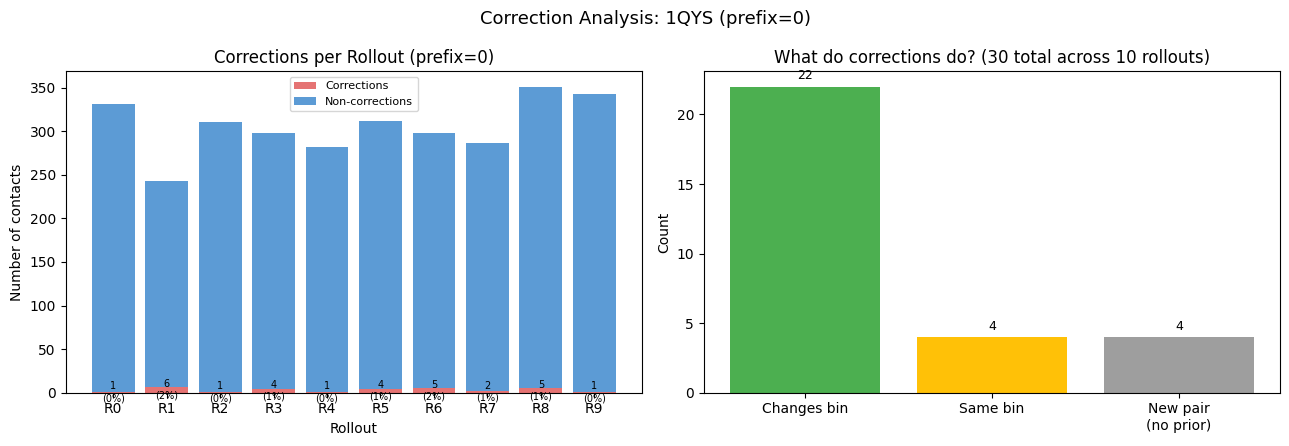

In [14]:
# Correction usage across rollouts
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: corrections per rollout
ax = axes[0]
rollouts_0 = rollout_contacts[0]
n_corrections = [sum(1 for c in r if c[0]) for r in rollouts_0]
n_total = [len(r) for r in rollouts_0]
pct_corrections = [100 * nc / nt if nt > 0 else 0 for nc, nt in zip(n_corrections, n_total)]

x = range(N_ROLLOUTS)
bars = ax.bar(x, n_corrections, color="#E57373", label="Corrections")
ax.bar(x, [nt - nc for nt, nc in zip(n_total, n_corrections)],
       bottom=n_corrections, color="#5C9BD5", label="Non-corrections")
ax.set_xlabel("Rollout")
ax.set_ylabel("Number of contacts")
ax.set_title("Corrections per Rollout (prefix=0)")
ax.set_xticks(x)
ax.set_xticklabels([f"R{i}" for i in x])
ax.legend(fontsize=8)
for i, (nc, pct) in enumerate(zip(n_corrections, pct_corrections)):
    if nc > 0:
        ax.text(i, nc / 2, f"{nc}\n({pct:.0f}%)", ha="center", va="center", fontsize=7)

# Right: are corrections actually correcting? Check if a correction's residue pair
# was previously seen as non-correction with a different bin
ax = axes[1]
correction_stats = {"corrects_bin": 0, "same_bin": 0, "new_pair": 0, "total": 0}
for rollout in rollouts_0:
    seen_pairs = {}  # (p1, p2) -> last bin
    for is_corr, p1, p2, a1, a2, bin_tok in rollout:
        pair = (p1, p2)
        if is_corr:
            correction_stats["total"] += 1
            if pair in seen_pairs:
                if seen_pairs[pair] != bin_tok:
                    correction_stats["corrects_bin"] += 1
                else:
                    correction_stats["same_bin"] += 1
            else:
                correction_stats["new_pair"] += 1
        seen_pairs[pair] = bin_tok

labels = ["Changes bin", "Same bin", "New pair\n(no prior)"]
values = [correction_stats["corrects_bin"], correction_stats["same_bin"],
          correction_stats["new_pair"]]
colors = ["#4CAF50", "#FFC107", "#9E9E9E"]
bars = ax.bar(labels, values, color=colors)
ax.set_ylabel("Count")
ax.set_title(f"What do corrections do? ({correction_stats['total']} total across {N_ROLLOUTS} rollouts)")
for bar in bars:
    if bar.get_height() > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                str(int(bar.get_height())), ha="center", va="bottom", fontsize=9)

plt.suptitle(f"Correction Analysis: {PDB_ID} (prefix=0)", fontsize=13)
plt.tight_layout()
plt.show()


pLDDT tokens across rollouts (prefix=0):
  None: 7/10 rollouts
  plddt_90_95: 3/10 rollouts


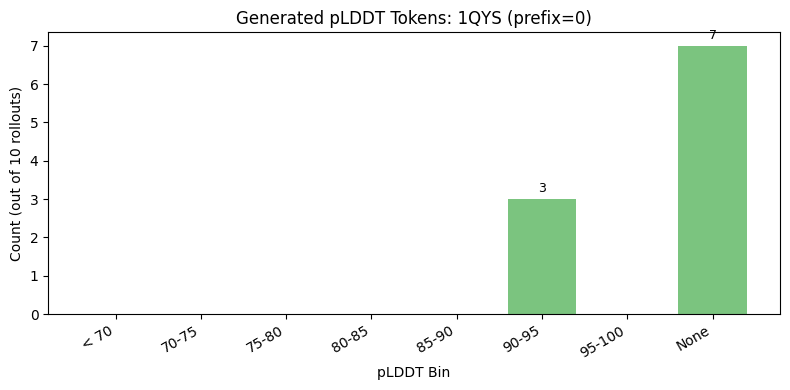

In [15]:
# pLDDT token distribution across rollouts
plddts_0 = rollout_plddts[0]

print("pLDDT tokens across rollouts (prefix=0):")
plddt_counts = Counter(plddts_0)
for tok, count in sorted(plddt_counts.items(), key=lambda x: str(x[0])):
    print(f"  {tok}: {count}/{N_ROLLOUTS} rollouts")

# Plot distribution
fig, ax = plt.subplots(figsize=(8, 4))

all_plddt_tokens = [
    "plddt_lt70", "plddt_70_75", "plddt_75_80", "plddt_80_85",
    "plddt_85_90", "plddt_90_95", "plddt_95_100", None,
]
plddt_labels = [
    "< 70", "70-75", "75-80", "80-85", "85-90", "90-95", "95-100", "None"
]
counts = [plddt_counts.get(tok, 0) for tok in all_plddt_tokens]

bars = ax.bar(range(len(plddt_labels)), counts, color="#7BC47F")
ax.set_xticks(range(len(plddt_labels)))
ax.set_xticklabels(plddt_labels, rotation=30, ha="right")
ax.set_xlabel("pLDDT Bin")
ax.set_ylabel(f"Count (out of {N_ROLLOUTS} rollouts)")
ax.set_title(f"Generated pLDDT Tokens: {PDB_ID} (prefix=0)")

for bar in bars:
    if bar.get_height() > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                str(int(bar.get_height())), ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()


Atom validity (prefix=0):
  Ground truth: 100.0% (514/514)
  Rollouts: mean=99.6%, min=96.6%, max=100.0%
    R0: 100.0% (662/662)
    R1: 100.0% (486/486)
    R2: 100.0% (622/622)
    R3: 96.6% (576/596)
    R4: 100.0% (564/564)
    R5: 99.8% (623/624)
    R6: 99.8% (595/596)
    R7: 100.0% (572/572)
    R8: 99.4% (698/702)
    R9: 99.9% (683/684)


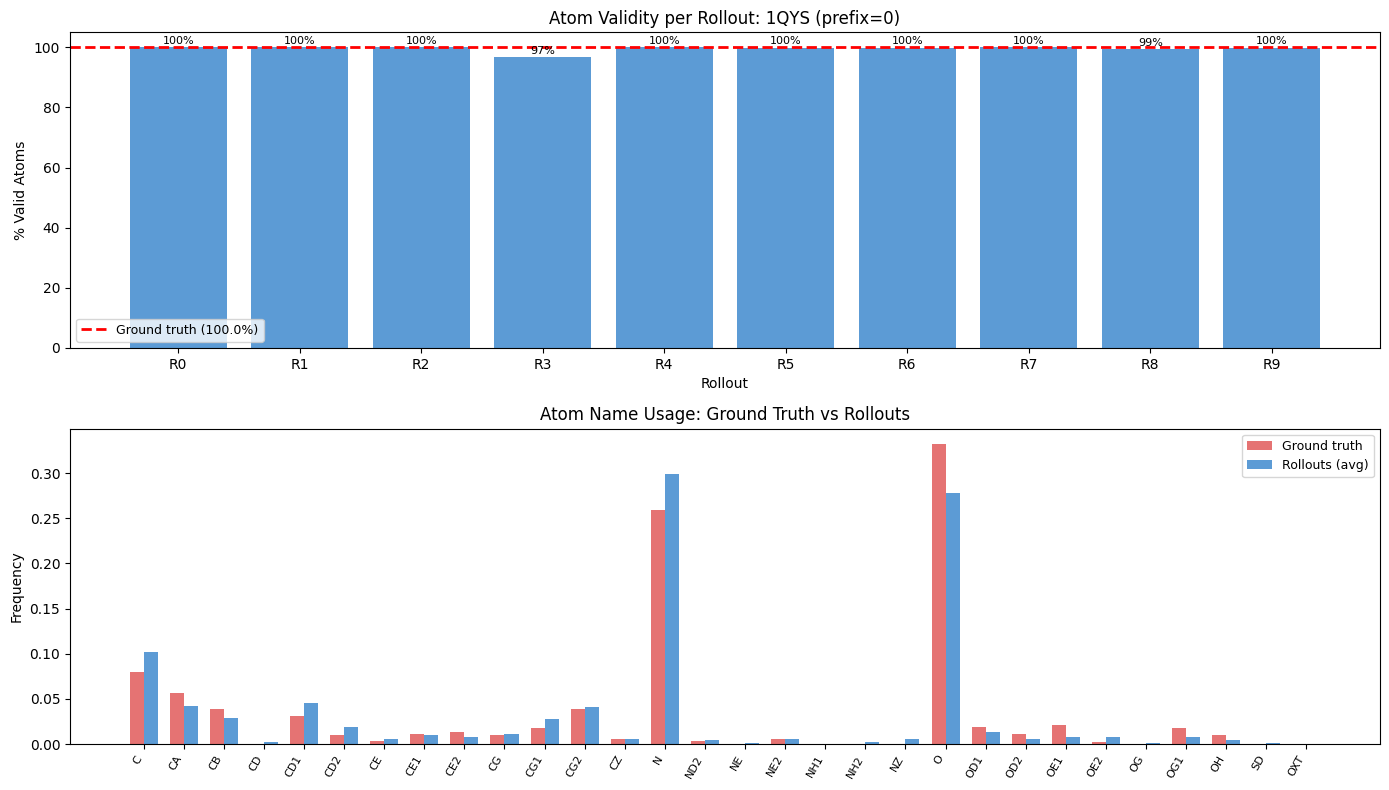

In [16]:
# Atom validity and atom name usage: ground truth vs rollouts
from experiments.exp5_contact_prediction.src.train import check_atom_validity
from experiments.exp5_contact_prediction.src.data import ATOM_NAMES

# Atom validity across rollouts
rollouts_0 = rollout_contacts[0]
valid_counts = []
total_counts = []
for rollout in rollouts_0:
    v, t = check_atom_validity(rollout, sequence)
    valid_counts.append(v)
    total_counts.append(t)

pct_valid = [100 * v / t if t > 0 else 0 for v, t in zip(valid_counts, total_counts)]
gt_v, gt_t = check_atom_validity(gt_contacts, sequence)
gt_pct = 100 * gt_v / gt_t if gt_t > 0 else 0

print(f"Atom validity (prefix=0):")
print(f"  Ground truth: {gt_pct:.1f}% ({gt_v}/{gt_t})")
print(f"  Rollouts: mean={np.mean(pct_valid):.1f}%, min={np.min(pct_valid):.1f}%, max={np.max(pct_valid):.1f}%")
for i, (v, t, pct) in enumerate(zip(valid_counts, total_counts, pct_valid)):
    print(f"    R{i}: {pct:.1f}% ({v}/{t})")

# Count atom name usage in GT vs rollouts
gt_atom_counts = Counter()
for c in gt_contacts:
    gt_atom_counts[c[3]] += 1  # atom1
    gt_atom_counts[c[4]] += 1  # atom2

rollout_atom_counts = Counter()
for rollout in rollouts_0:
    for c in rollout:
        rollout_atom_counts[c[3]] += 1
        rollout_atom_counts[c[4]] += 1

# Normalize to frequencies
gt_total = sum(gt_atom_counts.values())
rollout_total = sum(rollout_atom_counts.values())

# Use all atom names that appear in either
used_atoms = sorted(set(gt_atom_counts.keys()) | set(rollout_atom_counts.keys()),
                    key=lambda a: ATOM_NAMES.index(a) if a in ATOM_NAMES else 999)

gt_freqs = [gt_atom_counts.get(a, 0) / gt_total for a in used_atoms]
rollout_freqs = [rollout_atom_counts.get(a, 0) / rollout_total for a in used_atoms]

# Plot
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Top: atom validity bar chart
ax = axes[0]
x = range(N_ROLLOUTS)
bars = ax.bar(x, pct_valid, color="#5C9BD5")
ax.axhline(gt_pct, color="red", linewidth=2, linestyle="--", label=f"Ground truth ({gt_pct:.1f}%)")
ax.set_xlabel("Rollout")
ax.set_ylabel("% Valid Atoms")
ax.set_title(f"Atom Validity per Rollout: {PDB_ID} (prefix=0)")
ax.set_xticks(x)
ax.set_xticklabels([f"R{i}" for i in x])
ax.set_ylim(0, 105)
ax.legend(fontsize=9)
for bar, pct in zip(bars, pct_valid):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{pct:.0f}%", ha="center", va="bottom", fontsize=8)

# Bottom: atom name frequency comparison
ax = axes[1]
x_pos = np.arange(len(used_atoms))
width = 0.35
bars1 = ax.bar(x_pos - width/2, gt_freqs, width, label="Ground truth", color="#E57373")
bars2 = ax.bar(x_pos + width/2, rollout_freqs, width, label="Rollouts (avg)", color="#5C9BD5")
ax.set_xticks(x_pos)
ax.set_xticklabels(used_atoms, rotation=60, ha="right", fontsize=8)
ax.set_ylabel("Frequency")
ax.set_title(f"Atom Name Usage: Ground Truth vs Rollouts")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()
